# An ML-based system for classifying groundwater samples according to Indian drinking-water safety standards

## Project Workflow

1. Data Collection
   |
2. Data Understanding & Initial Inspection
   |
3. Data Cleaning & Preprocessing
   |
4. Missing Value Analysis & Handling
   |
5. Exploratory Data Analysis (EDA)
   |
6. Outlier Detection & Removal (IQR method)
   |
7. Correlation & Feature Analysis
   |
8. Contamination Label Creation Using Chemical Thresholds
   |
9. Feature & Target Selection
   |
10. Train-Test Split
   |
11. Feature Preprocessing, Imputation & SMOTE Class Balancing
   |
12. Logistic Regression Model (GridSearchCV Hyperparameter Tuning)
   |
13. Decision Tree Model (GridSearchCV Hyperparameter Tuning)
   |
14. Logistic Regression + Decision Tree Ensemble (Soft Voting)
   |
15. Threshold Optimization
   |
16. Final Model Evaluation
   |
17. Feature Importance & Model Interpretation
   |
18. Final Insights & Conclusion


### Steps after data importing

1. Data validation
2. Missing-value analysis
3. Outlier detection & visualization
4. Outlier **removal** via the IQR method (applied before label creation — see the note further down on what this does to the Contaminated class)
5. EDA
6. Define Safe/Contaminated target
7. Feature engineering
8. Train/test split
9. SMOTE class balancing (training data only)
10. Model training with GridSearchCV hyperparameter tuning
11. Soft-voting ensemble of both tuned models
12. Model evaluation
13. Feature importance / interpretation


### STEP BY STEP

1. Load Data (CSV → pandas → MySQL)
         |
2. Basic Inspection
   (shape, dtypes, missing value counts, summary stats)
         |
3. Fix Physically Impossible Values ONLY
   (negative Mg → NaN, pH outside 0–14 → NaN)
   ← NOT full outlier removal yet
         |
4. CREATE THE LABEL HERE (while extreme values still exist)
   contaminated = 1 if ANY of 8 BIS rules broken
   (ph, cl, f, so4, no3, total_hardness, ca, mg)
   ← This is the critical fix. Label must see Ca=500,
     NO3=200, F=8 etc. before they get removed.
         |
5. EDA & Visualizations
   (boxplots, histograms, correlation heatmap,
    safe vs contaminated distribution)
         |
6. NOW Remove Outliers (IQR method)
   ← Features get cleaned, but the label column
     is already set and stays untouched.
   ← Print class balance before and after
     so the impact is visible.
         |
7. Feature & Target Selection
   X = 13 chemical columns
   y = contaminated
         |
8. 80/20 Stratified Train-Test Split
         |
9. Median Imputation
   (fit on training set only, transform both)
         |
10. SMOTE
    (training set only — test set never touched)
    ← Adaptive k_neighbors in case minority
      class is still small after step 6
         |
11. StandardScaler
    (fit on SMOTE-balanced training set,
     transform both — for LR only)
         |
12. GridSearchCV — Logistic Regression
    (C: [0.01, 0.1, 1, 10, 100], scoring=f1, cv=5)
         |
13. GridSearchCV — Decision Tree
    (max_depth, min_samples_split,
     min_samples_leaf, criterion, scoring=f1, cv=5)
         |
14. Soft-Voting Ensemble
    ensemble_prob = (lr_prob + dt_prob) / 2
    ← Verified against VotingClassifier(voting='soft')
         |
15. Threshold Sweep (0.20 → 0.50)
    Auto-select threshold that maximises F1
         |
16. Final Evaluation on Test Set
    (accuracy, precision, recall, F1, ROC-AUC,
     confusion matrix)
         |
17. 5-Fold Cross-Validation
    (SMOTE inside each fold, tuned hyperparameters,
     soft voting, selected threshold)
         |
18. Feature Importance & Interpretation
    (DT importances, LR coefficients)
         |
19. False Negative Analysis
    (which samples were missed, which BIS
     rule was violated, probability distribution)
         |
20. Save Artifacts (joblib)
    model_lr.pkl, model_dt.pkl,
    imputer.pkl, scaler.pkl,
    prediction_threshold.pkl, feature_order.pkl

In [1]:
pip install pypdf pandas numpy

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


#### import pypdf
import pandas as pd
import numpy as np
import re

#Load the PDF
pdf_path = "final_nhs-wq_pre_2023_compressed.pdf"
reader = pypdf.PdfReader(pdf_path)

all_pdf_text = []
for page in reader.pages:
    txt = page.extract_text()
    if txt:
        all_pdf_text.append(txt)

full_pdf_str = "\n".join(all_pdf_text)
pdf_lines = full_pdf_str.split("\n")

#Known States and UTs
known_states = [
    'Andaman & Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam',
    'Bihar', 'Chandigarh Ut', 'Chhattisgarh', 'Dadra And Nagar Haveli',
    'Daman And Diu', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
    'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh',
    'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya',
    'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan',
    'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
    'Uttarakhand', 'West Bengal'
]

#Known Districts
unique_districts = [
    'North & Middle Andaman', 'South Andaman', 'Nicobar',
    'Changlang', 'East Siang', 'Lohit', 'Papumpare', 'Tirap',
    'Baksa', 'Bongaigaon', 'Cachar', 'Darrang', 'Dhubri', 'Dibrugarh', 'East Karbi Anglong',
    'Goalpara', 'Golaghat', 'Hailakandi', 'Hojai', 'Jorhat', 'Kamrup', 'Karimganj',
    'Morigaon', 'Nagaon', 'Nalbari', 'Sonitpur', 'Tezpur', 'Tinsukia', 'Udalguri', 'West Karbi Anglong',
    'Biswanath', 'Dhemaji', 'Lakhimpur', 'Araria', 'Arwal', 'Aurangabad', 'Banka', 'Begusarai',
    'Bhagalpur', 'Bhojpur', 'Buxar', 'Darbhanga', 'East Chamapran', 'East Champaran', 'Gaya',
    'Gopalganj', 'Jamui', 'Jehanabad', 'Kaimur', 'Katihar', 'Khagaria', 'Kishanganj', 'Lakhisarai',
    'Madhepura', 'Madhubani', 'Munger', 'Muzzafarpur', 'Muzaffarpur', 'Nalanda', 'Nawada', 'Patna',
    'Purnea', 'Rohtas', 'Saharsa', 'Samastipur', 'Saran', 'Seikhpura', 'Sheikhpura', 'Sheohar',
    'Sitamarhi', 'Siwan', 'Supaul', 'Vaishali', 'West Champaran', 'Chandigarh', 'Balod', 'Balodabazar',
    'Balrampur', 'Bastar', 'Bemetara', 'Bilaspur', 'Dhamtari', 'Durg', 'Gariyabandh', 'Janjgir Champa',
    'Jashpur', 'Kanker', 'Kawardha', 'Kondagaon', 'Korba', 'Koriya', 'Mahasamund', 'Mungeli',
    'Raigarh', 'Raipur', 'Rajnandgaon', 'Surajpur', 'Surguja', 'Dadra And Nagar Haveli',
    'Daman', 'Diu', 'Ahmedabad', 'Amreli', 'Anand', 'Arvalli', 'Banaskantha', 'Bharuch', 'Bhavnagar',
    'Botad', 'Chhota Udepur', 'Dahod', 'Dang', 'Devbhoomi Dwarka', 'Devbhumi Dwarka', 'Gir Somnath',
    'Jamnagar', 'Junagadh', 'Kachchh', 'Kheda', 'Mahesana', 'Mahisagar', 'Morbi', 'Narmada', 'Navsari',
    'Panchmahal', 'Patan', 'Porbandar', 'Rajkot', 'Sabarkantha', 'Surat', 'Surendranagar', 'Tapi',
    'Vadodara', 'Valsad', 'Chamba', 'Hamirpur', 'Kangra', 'Kullu', 'Mandi', 'Sirmour', 'Solan', 'Una',
    'Reasi', 'Baramulla', 'Handwara', 'Jammu', 'Kathua', 'Kupwara', 'Mahreen', 'Rajouri', 'Samba', 'Udhampur',
    'Bokaro', 'Chatra', 'Deoghar', 'Dhanbad', 'Dumka', 'E. Singhbhum', 'East Singhbhum', 'Garhwa', 'Giridih',
    'Godda', 'Gumla', 'Hazaribagh', 'Jamtara', 'Khunti', 'Koderma', 'Latehar', 'Loherdaga', 'Lohardaga',
    'Pakur', 'Palamu', 'Ramgarh', 'Ranchi', 'Sahebganj', 'Saraikela', 'Simdega'
]

#Parse Rows and Map Parameters
records = []
for line in pdf_lines:
    line_str = line.strip()
    m = re.match(r'^(\d+)\s+(.+)$', line_str)
    if not m:
        continue
    
    s_no = m.group(1)
    rest = m.group(2)
    tokens = rest.split()
    
    if len(tokens) >= 20:
        tail = tokens[-20:]
        head = tokens[:-20]
        head_str = " ".join(head)
        
        # State matching
        matched_state = "Unknown"
        for st in sorted(known_states, key=len, reverse=True):
            if head_str.startswith(st):
                matched_state = st
                break
        
        if matched_state != "Unknown":
            rem_head = head_str[len(matched_state):].strip()
        else:
            matched_state = head[0] if len(head) > 0 else "Unknown"
            rem_head = " ".join(head[1:]) if len(head) > 1 else ""
            
        # District & Location matching
        matched_dist = ""
        matched_loc = rem_head
        for dst in sorted(unique_districts, key=len, reverse=True):
            if rem_head.lower().startswith(dst.lower()):
                matched_dist = dst
                matched_loc = rem_head[len(dst):].strip()
                break
                
        if not matched_dist:
            parts = rem_head.split()
            if len(parts) >= 2:
                matched_dist = parts[0]
                matched_loc = " ".join(parts[1:])
            elif len(parts) == 1:
                matched_dist = parts[0]
                matched_loc = parts[0]
                
        row_dict = {
            's_no': int(s_no),
            'state': matched_state,
            'district': matched_dist,
            'location': matched_loc,
            'longitude': tail[0],
            'latitude': tail[1],
            'year': tail[2],
            'ph': tail[3],
            'ec': tail[4],
            'co3': tail[5],
            'hco3': tail[6],
            'cl': tail[7],
            'f': tail[8],
            'so4': tail[9],
            'no3': tail[10],
            'po4': tail[11],
            'total_hardness': tail[12],
            'ca': tail[13],
            'mg': tail[14],
            'na': tail[15],
            'k': tail[16],
            'fe': tail[17],
            'as_ppb': tail[18],
            'u_ppb': tail[19]
        }
        records.append(row_dict)

#Build DataFrame & Cast Types
df = pd.DataFrame(records)
df.replace(['-', ' - ', 'NA', 'BDL', 'ND', 'nil', 'NIL', '#REF!'], np.nan, inplace=True)

num_cols = [
    'longitude', 'latitude', 'year', 'ph', 'ec', 'co3', 'hco3', 
    'cl', 'f', 'so4', 'no3', 'po4', 'total_hardness', 'ca', 'mg', 
    'na', 'k', 'fe', 'as_ppb', 'u_ppb'
]

for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

#Save directly to CSV
df.to_csv("groundwater_cleaned_dataset.csv", index=False)
print(f"Extraction Complete! Successfully exported 'groundwater_cleaned_dataset.csv' with {len(df)} rows.")

### CONNECT TO MYSQL

In [2]:
from sqlalchemy import create_engine

In [3]:
import pandas as pd

#loading the csv and then connecting it to mysql because direct sql import was throwing some errors
df = pd.read_csv('groundwater_sorted.csv')


user = 'root'
password = "14826571N" 
host = 'localhost'
database = 'groundwater_db'       


engine = create_engine(f'mysql+pymysql://{user}:{password}@{host}/{database}')

#uploadting df to sql
df.to_sql('groundwater_quality', con=engine, if_exists='replace', index=False)
print(f"Successfully uploaded {len(df)} rows to table 'groundwater_quality' in MySQL!")

Successfully uploaded 16673 rows to table 'groundwater_quality' in MySQL!


### EXPLORATORY DATA ANALYSIS (EDA)

In [82]:
df

,s_no,state,district,location,longitude,latitude,year,ph,ec,co3,...,po4,total_hardness,ca,mg,na,k,fe,as_ppb,u_ppb,contaminated
0,1,Andaman & Nicobar Islands,North & Middle Andaman,Bakultala,92.85770,12.50430,2023,7.96,395.0,0.0,...,0.04,160.0,12.0,32.0,18.0,5.0,0.530,NaN,NaN,0
1,2,Andaman & Nicobar Islands,North & Middle Andaman,Baratang (Nilambur),92.76700,12.16830,2023,8.19,473.0,0.0,...,0.03,135.0,26.0,17.0,39.0,5.0,0.000,NaN,NaN,0
2,3,Andaman & Nicobar Islands,North & Middle Andaman,Basantipur,92.87370,12.75790,2023,8.19,556.0,0.0,...,0.05,230.0,38.0,33.0,22.0,1.0,0.220,NaN,NaN,0
3,4,Andaman & Nicobar Islands,North & Middle Andaman,Betapur,92.94340,12.61910,2023,8.07,487.0,0.0,...,0.08,95.0,18.0,12.0,68.0,8.0,0.040,NaN,NaN,0
4,5,Andaman & Nicobar Islands,North & Middle Andaman,Dhobidera (Mayabunder),92.89920,12.90990,2023,8.02,567.0,0.0,...,0.04,230.0,28.0,39.0,31.0,1.0,0.220,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11454,16772,Odisha,SONAPUR,Sindol,83.67194,20.70694,2023,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.636,17.856,0
11455,16773,Odisha,SONAPUR,Singhijuba,83.90417,20.85222,2023,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.141,5.775,0
11456,16774,Odisha,SONAPUR,Sonepur,84.16806,20.89389,2023,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.110,14.674,0
11457,16775,Odisha,SONAPUR,Subalaya,84.17694,20.90750,2023,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2.144,0.076,0.419,0


In [4]:
print("Shape of the data:",df.shape)

Shape of the data: (16673, 24)


In [5]:
print("Name of columns:",df.columns)

Name of columns: Index(['s_no', 'state', 'district', 'location', 'longitude', 'latitude',
       'year', 'ph', 'ec', 'co3', 'hco3', 'cl', 'f', 'so4', 'no3', 'po4',
       'total_hardness', 'ca', 'mg', 'na', 'k', 'fe', 'as_ppb', 'u_ppb'],
      dtype='object')


In [6]:
print("First 5 rows:",df.head())

First 5 rows:    s_no                      state                district  \
0     1  Andaman & Nicobar Islands  North & Middle Andaman   
1     2  Andaman & Nicobar Islands  North & Middle Andaman   
2     3  Andaman & Nicobar Islands  North & Middle Andaman   
3     4  Andaman & Nicobar Islands  North & Middle Andaman   
4     5  Andaman & Nicobar Islands  North & Middle Andaman   

                 location  longitude  latitude  year    ph     ec  co3  ...  \
0               Bakultala    92.8577   12.5043  2023  7.96  395.0  0.0  ...   
1     Baratang (Nilambur)    92.7670   12.1683  2023  8.19  473.0  0.0  ...   
2              Basantipur    92.8737   12.7579  2023  8.19  556.0  0.0  ...   
3                 Betapur    92.9434   12.6191  2023  8.07  487.0  0.0  ...   
4  Dhobidera (Mayabunder)    92.8992   12.9099  2023  8.02  567.0  0.0  ...   

    no3   po4  total_hardness    ca    mg    na    k    fe  as_ppb  u_ppb  
0   8.0  0.04           160.0  12.0  32.0  18.0  5.0  0.53    

In [7]:
print("Information on data (Data Types):",df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16673 entries, 0 to 16672
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   s_no            16673 non-null  int64  
 1   state           16673 non-null  object 
 2   district        16671 non-null  object 
 3   location        16670 non-null  object 
 4   longitude       16667 non-null  float64
 5   latitude        16668 non-null  float64
 6   year            16673 non-null  int64  
 7   ph              15155 non-null  float64
 8   ec              15156 non-null  float64
 9   co3             15156 non-null  float64
 10  hco3            15156 non-null  float64
 11  cl              15156 non-null  float64
 12  f               15156 non-null  float64
 13  so4             15156 non-null  float64
 14  no3             15156 non-null  float64
 15  po4             8465 non-null   float64
 16  total_hardness  15156 non-null  float64
 17  ca              15156 non-null 

In [8]:
print("Total number of null values in each column:\n",df.isnull().sum())

Total number of null values in each column:
 s_no                 0
state                0
district             2
location             3
longitude            6
latitude             5
year                 0
ph                1518
ec                1517
co3               1517
hco3              1517
cl                1517
f                 1517
so4               1517
no3               1517
po4               8208
total_hardness    1517
ca                1517
mg                1517
na                1517
k                 1519
fe                8918
as_ppb            9679
u_ppb             5314
dtype: int64


In [9]:
print("Statistical Information on column:",df.describe().T)  #t for transpoase

Statistical Information on column:                   count         mean          std      min          25%  \
s_no            16673.0  8385.615726  4855.545573     1.00  4169.000000   
longitude       16667.0    79.692735     5.420865     3.00    76.293900   
latitude        16668.0    22.257467     6.222890     3.00    18.486875   
year            16673.0  2023.000000     0.000000  2023.00  2023.000000   
ph              15155.0     7.686403     0.442879     2.54     7.440000   
ec              15156.0  1300.274215  1821.595186    12.00   548.000000   
co3             15156.0     5.580562    44.692200     0.00     0.000000   
hco3            15156.0   344.208894   203.147616     0.00   210.000000   
cl              15156.0   187.939562   575.775154     0.00    28.000000   
f               15156.0     0.737993     0.978487     0.00     0.260000   
so4             15156.0    79.460346   185.781794     0.00    10.000000   
no3             15156.0    32.854909    69.092956     0.00     3.

In [10]:
print("Unique values:\n",df.nunique())
print("\n\nNumber of States and Districts studied:\n",df[['state','district']].nunique())

Unique values:
 s_no              16673
state                34
district            625
location          14859
longitude         14560
latitude          15004
year                  1
ph                  336
ec                 3154
co3                 129
hco3                788
cl                 1037
f                   433
so4                 730
no3                 385
po4                 106
total_hardness     1050
ca                  355
mg                  334
na                  969
k                   306
fe                  809
as_ppb             1299
u_ppb              2954
dtype: int64


Number of States and Districts studied:
 state        34
district    625
dtype: int64


In [11]:
print("Total number of entries across the year:\n",df['year'].value_counts().sort_index())

Total number of entries across the year:
 year
2023    16673
Name: count, dtype: int64


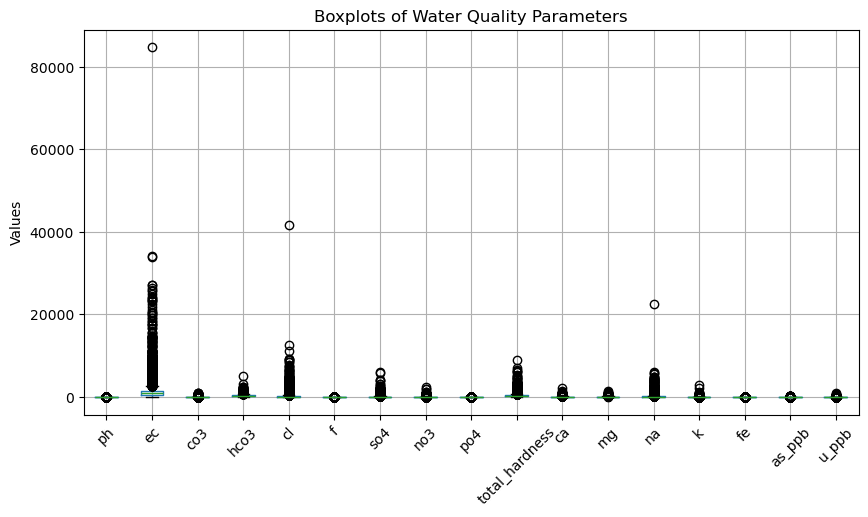

In [12]:
#CHecking for outliers using boxplot

import matplotlib.pyplot as plt

df.select_dtypes(include='number').drop(columns=['s_no', 'year','latitude','longitude']).boxplot(figsize=(10,5),rot=45)

plt.title("Boxplots of Water Quality Parameters")
plt.ylabel("Values")
plt.show()

### CHECKING FOR OUTLIERS USING IQR

In [13]:
#columns containing water quality data
water_cols = ['ph', 'ec', 'co3', 'hco3', 'cl', 'f', 'so4', 'no3','po4', 'total_hardness', 'ca', 'mg', 'na', 'k','fe', 'as_ppb', 'u_ppb']

#handling outliers using IQR
outlier_counts = {}

for col in water_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_counts[col] = len(outliers)

outlier_counts

{'ph': 325,
 'ec': 1299,
 'co3': 852,
 'hco3': 362,
 'cl': 1635,
 'f': 861,
 'so4': 1490,
 'no3': 1225,
 'po4': 1363,
 'total_hardness': 876,
 'ca': 738,
 'mg': 949,
 'na': 1532,
 'k': 1762,
 'fe': 1037,
 'as_ppb': 883,
 'u_ppb': 1269}

In [14]:
#easy to read df format 

outlier_df = pd.DataFrame(list(outlier_counts.items()),columns=['Parameter', 'Outlier_Count']).sort_values('Outlier_Count', ascending=False)

outlier_df

,Parameter,Outlier_Count
13,k,1762
4,cl,1635
12,na,1532
6,so4,1490
8,po4,1363
1,ec,1299
16,u_ppb,1269
7,no3,1225
14,fe,1037
11,mg,949


### LOOKING FPR MISSING VALUES

In [15]:
missing = pd.DataFrame({"Missing_Count": df.isnull().sum(),"Missing_Percentage": (df.isnull().sum() / len(df)*100).round(2)})

missing = missing[missing["Missing_Count"] > 0].sort_values("Missing_Percentage", ascending=False)

print(missing)

                Missing_Count  Missing_Percentage
as_ppb                   9679               58.05
fe                       8918               53.49
po4                      8208               49.23
u_ppb                    5314               31.87
k                        1519                9.11
no3                      1517                9.10
na                       1517                9.10
mg                       1517                9.10
ca                       1517                9.10
total_hardness           1517                9.10
so4                      1517                9.10
f                        1517                9.10
cl                       1517                9.10
hco3                     1517                9.10
co3                      1517                9.10
ec                       1517                9.10
ph                       1518                9.10
longitude                   6                0.04
latitude                    5                0.03


In [16]:
#checking which state has higher concenteration of missing values

missing_by_state = df.groupby('state')[water_cols].apply(lambda x: x.isnull().mean() * 100)

missing_by_state.round(2)

,ph,ec,co3,hco3,cl,f,so4,no3,po4,total_hardness,ca,mg,na,k,fe,as_ppb,u_ppb
state,,,,,,,,,,,,,,,,,
Andaman & Nicobar Islands,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00,100.00
Andhra Pradesh,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00,0.00,0.00,0.00,0.00,0.00,100.00,100.00,100.00
Arunachal Pradesh,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Assam,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Bihar,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.25,100.00,100.00,6.93
Chandigarh Ut,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Chhattisgarh,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.26,0.00,0.00,0.00,0.00,0.00,100.00,100.00,0.00
Dadra And Nagar Haveli,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00,100.00
Daman And Diu,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00,100.00


In [17]:
#checking the missing data pattern across states and cities

df.groupby('state')[['as_ppb', 'fe', 'po4', 'u_ppb']].apply(lambda x: x.isnull().mean()*100).round(2)

#the data shows missing values aren't random. it's either that the data from the particular states was not recorded properly

,as_ppb,fe,po4,u_ppb
state,,,,
Andaman & Nicobar Islands,100.00,0.00,0.00,100.00
Andhra Pradesh,100.00,100.00,100.00,100.00
Arunachal Pradesh,0.00,0.00,100.00,0.00
Assam,0.00,0.00,100.00,0.00
Bihar,100.00,100.00,0.00,6.93
Chandigarh Ut,0.00,0.00,0.00,0.00
Chhattisgarh,100.00,100.00,0.26,0.00
Dadra And Nagar Haveli,100.00,0.00,100.00,100.00
Daman And Diu,100.00,0.00,100.00,100.00


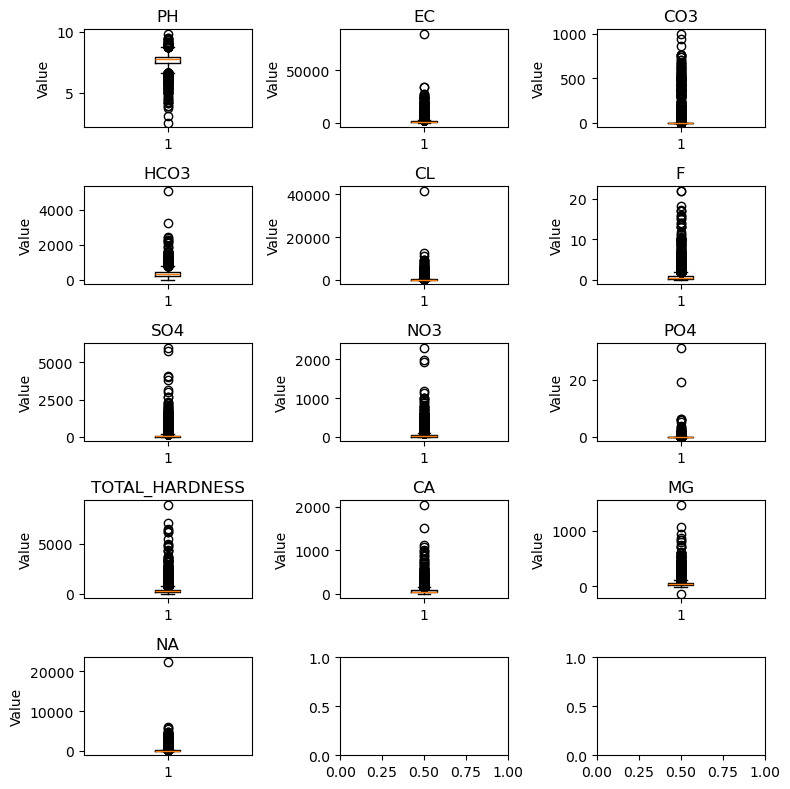

In [18]:
#actual distribution and extreme values of the chemical parameters

fig, axes = plt.subplots(5, 3, figsize=(8, 8))

cols = ['ph','ec','co3','hco3','cl','f','so4','no3','po4','total_hardness','ca','mg','na',]

for ax, col in zip(axes.flatten(), cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(col.upper())
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

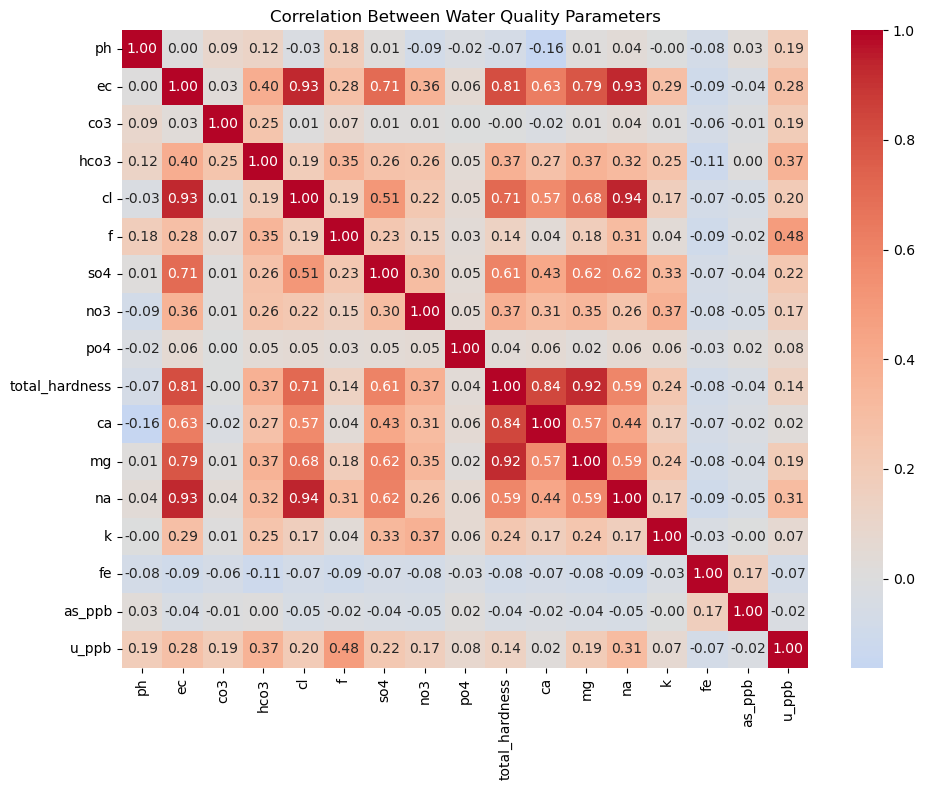

In [19]:
import seaborn as sns

corr = df[water_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",center=0)

plt.title("Correlation Between Water Quality Parameters")
plt.tight_layout()
plt.show()

### ANALYSING MISSING VALUES

In [20]:
missing = pd.DataFrame({"Missing_Count": df.isnull().sum(),"Missing_Percentage": (df.isnull().sum() / len(df)*100).round(2)})

missing = missing[missing["Missing_Count"] > 0].sort_values("Missing_Percentage", ascending=False)

print(missing)

                Missing_Count  Missing_Percentage
as_ppb                   9679               58.05
fe                       8918               53.49
po4                      8208               49.23
u_ppb                    5314               31.87
k                        1519                9.11
no3                      1517                9.10
na                       1517                9.10
mg                       1517                9.10
ca                       1517                9.10
total_hardness           1517                9.10
so4                      1517                9.10
f                        1517                9.10
cl                       1517                9.10
hco3                     1517                9.10
co3                      1517                9.10
ec                       1517                9.10
ph                       1518                9.10
longitude                   6                0.04
latitude                    5                0.03


In [21]:
#removing the missing geographic information first

df = df.dropna(subset=['district', 'location', 'latitude', 'longitude'])
print("Null values dropped from the mentioned columns...")
df.isnull().sum()

Null values dropped from the mentioned columns...


s_no                 0
state                0
district             0
location             0
longitude            0
latitude             0
year                 0
ph                1514
ec                1513
co3               1513
hco3              1513
cl                1513
f                 1513
so4               1513
no3               1513
po4               8202
total_hardness    1513
ca                1513
mg                1513
na                1513
k                 1515
fe                8916
as_ppb            9675
u_ppb             5311
dtype: int64

In [22]:
#handling the columns with less missing values first i.e around 1000-1500 null values that makes up to about 9-10% of the missing data per column

core_chemicals = ['ph', 'ec', 'co3', 'hco3', 'cl', 'f','so4', 'no3', 'total_hardness','ca', 'mg', 'na', 'k']
df[core_chemicals].isnull().sum()

ph                1514
ec                1513
co3               1513
hco3              1513
cl                1513
f                 1513
so4               1513
no3               1513
total_hardness    1513
ca                1513
mg                1513
na                1513
k                 1515
dtype: int64

In [23]:
print("Rows with all core chemical values present:",df[core_chemicals].dropna().shape[0])


Rows with all core chemical values present: 15149


In [24]:
high_missing = ['po4', 'fe', 'as_ppb', 'u_ppb']

print("Rows with at least one high-missing parameter:",df[high_missing].notna().any(axis=1).sum())

print("Rows with all four high-missing parameters:",df[high_missing].notna().all(axis=1).sum())

Rows with at least one high-missing parameter: 13688
Rows with all four high-missing parameters: 4054


### HANDLING OUTLIERS USING IQR

In [25]:
outlier_summary = []

for col in core_chemicals:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) |(df[col] > upper_bound)][col].count()

    outlier_summary.append([col,Q1,Q3,IQR,lower_bound,upper_bound,outliers])

outlier_summary = pd.DataFrame(outlier_summary,columns=['Parameter','Q1','Q3','IQR','Lower_Bound','Upper_Bound','Outlier_Count'])

outlier_summary

,Parameter,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,ph,7.44,7.97,0.53,6.645,8.765,325
1,ec,548.00,1413.00,865.00,-749.500,2710.500,1299
2,co3,0.00,0.00,0.00,0.000,0.000,852
3,hco3,211.50,445.00,233.50,-138.750,795.250,363
4,cl,28.00,163.00,135.00,-174.500,365.500,1635
5,f,0.26,0.91,0.65,-0.715,1.885,861
6,so4,10.00,75.00,65.00,-87.500,172.500,1490
7,no3,3.00,37.00,34.00,-48.000,88.000,1225
8,total_hardness,180.00,400.00,220.00,-150.000,730.000,876
9,ca,32.00,80.00,48.00,-40.000,152.000,738


In [26]:
df[core_chemicals].describe().T

,count,mean,std,min,25%,50%,75%,max
ph,15151.0,7.686305,0.442884,2.54,7.44,7.74,7.97,9.85
ec,15152.0,1300.450700,1821.796225,12.00,548.00,876.00,1413.00,84660.00
co3,15152.0,5.582035,44.698007,0.00,0.00,0.00,0.00,1001.00
hco3,15152.0,344.248614,203.153456,0.00,211.50,329.00,445.00,5078.00
cl,15152.0,187.965813,575.847715,0.00,28.00,68.00,163.00,41665.00
f,15152.0,0.738105,0.978587,0.00,0.26,0.52,0.91,22.00
so4,15152.0,79.472413,185.804494,0.00,10.00,33.00,75.00,5981.00
no3,15152.0,32.861338,69.100837,0.00,3.00,13.00,37.00,2296.00
total_hardness,15152.0,338.848799,329.372983,0.00,180.00,276.00,400.00,8847.00
ca,15152.0,65.564546,60.985356,1.00,32.00,52.00,80.00,2044.00


In [27]:
for col in core_chemicals:
    print(f"\n{col}")
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())


ph
Minimum: 2.54
Maximum: 9.85

ec
Minimum: 12.0
Maximum: 84660.0

co3
Minimum: 0.0
Maximum: 1001.0

hco3
Minimum: 0.0
Maximum: 5078.0

cl
Minimum: 0.0
Maximum: 41665.0

f
Minimum: 0.0
Maximum: 22.0

so4
Minimum: 0.0
Maximum: 5981.0

no3
Minimum: 0.0
Maximum: 2296.0

total_hardness
Minimum: 0.0
Maximum: 8847.0

ca
Minimum: 1.0
Maximum: 2044.0

mg
Minimum: -141.0
Maximum: 1474.0

na
Minimum: 0.0
Maximum: 22437.0

k
Minimum: 0.0
Maximum: 2895.0


In [28]:
#Count the invalid or maybe negative Mg values

negative_mg = df[df['mg'] < 0]

print("Negative Mg values:", len(negative_mg))

negative_mg[['state', 'district', 'location', 'mg']]

Negative Mg values: 3


,state,district,location,mg
2277,Gujarat,Morbi,Malia,-10.0
2367,Gujarat,Rajkot,Dadia,-17.0
2513,Gujarat,Valsad,Khadakval,-141.0


In [29]:
import numpy as np

#replacing the negative values with NaN

df.loc[df['mg'] < 0, 'mg'] = np.nan

In [30]:
print("Negative Mg values:", (df['mg'] < 0).sum())
print("Missing Mg values:", df['mg'].isnull().sum())

Negative Mg values: 0
Missing Mg values: 1516


In [31]:
#checking for any other negative chemical values

for col in core_chemicals:
    negative_count = (df[col] < 0).sum()
    
    if negative_count > 0:
        print(f"{col}: {negative_count} negative values")
    

In [32]:
#invalid ph value check

invalid_ph = df[(df['ph'] < 0) | (df['ph'] > 14)]

print("Invalid pH values:", len(invalid_ph))

Invalid pH values: 0


### REMOVING OUTLIERS (IQR METHOD)

Earlier, outliers were only counted and inspected (boxplots and the outlier-count summary), not removed — because extreme chemical readings are often the contamination signal theee project is trying to detect, not noise. This section removes them anyway, as required.

**This is a meaningful methodological trade-off, not a free win.** The `contaminated` label (created just below) is itself defined by these same columns crossing BIS limits — values that the IQR method is very likely to flag as outliers. So removing outliers before labeling will shrink the Contaminated class. The cell right after label creation prints the resulting class balance so this trade-off is visible rather than hidden.

In [33]:
before_rows = df.shape[0]
print("Rows before outlier removal:", before_rows)

outlier_mask = pd.Series(False, index=df.index)

for col in core_chemicals:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask |= (df[col] < lower_bound) | (df[col] > upper_bound)

print("Rows flagged as outliers on at least one core chemical parameter:", outlier_mask.sum())

df = df[~outlier_mask].reset_index(drop=True)

after_rows = df.shape[0]
print("Rows after outlier removal:", after_rows)
print(f"Rows removed: {before_rows - after_rows} "
      f"({(before_rows - after_rows) / before_rows * 100:.1f}%)")


Rows before outlier removal: 16665
Rows flagged as outliers on at least one core chemical parameter: 5206
Rows after outlier removal: 11459
Rows removed: 5206 (31.2%)


In [34]:
#checking out the missing values now

missing_after_cleaning = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)})

missing_after_cleaning = missing_after_cleaning[missing_after_cleaning['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

print(missing_after_cleaning)

                Missing_Count  Missing_Percentage
as_ppb                   6118               53.39
fe                       5662               49.41
po4                      5658               49.38
u_ppb                    3362               29.34
mg                       1515               13.22
ph                       1514               13.21
cl                       1513               13.20
f                        1513               13.20
so4                      1513               13.20
no3                      1513               13.20
ec                       1513               13.20
total_hardness           1513               13.20
ca                       1513               13.20
na                       1513               13.20
k                        1513               13.20
hco3                     1513               13.20
co3                      1513               13.20


### DEFINING WHAT IS SAFE AND WHAT IS CONTAMINATED

In [35]:
#setting the threshold using BIS (Bereauu of Indian Standard) limits

bis_limits = {'ph': (6.5, 8.5),'ec': None,'co3': None,'hco3': None,'cl': 1000,'f': 1.5,'so4': 400,'no3': 45,
    'total_hardness': 600,'ca': 200,'mg': 100,'na': None,'k': None}

In [36]:
contamination_limits = {'ph': (6.5, 8.5),'cl': 1000,'f': 1.5,'so4': 400,'no3': 45,'total_hardness': 600,'ca': 200,
                        'mg': 100}

In [37]:
limits = {'ph': (6.5, 8.5),'cl': 1000,'f': 1.5,'so4': 400,'no3': 45,'total_hardness': 600,'ca': 200,'mg': 100}

contamination_flags = pd.DataFrame(index=df.index)

contamination_flags['ph'] = ((df['ph'] < 6.5) | (df['ph'] > 8.5))

for col, limit in limits.items():
    if col != 'ph':
        contamination_flags[col] = df[col] > limit

contamination_count = contamination_flags.sum(axis=1)

print("Potentially contaminated:", (contamination_count > 0).sum())
print("Potentially safe:", (contamination_count == 0).sum())

Potentially contaminated: 1225
Potentially safe: 10234


In [38]:
df['contaminated'] = (contamination_count > 0).astype(int)


print(df['contaminated'].value_counts())

contaminated
0    10234
1     1225
Name: count, dtype: int64


**Effect of outlier removal on the target label:** compare the class balance below against what it would have been without outlier removal — a large drop in the Contaminated share means the model is now learning from far fewer real contamination examples. This should be reported alongside the final results, not left out, since it directly affects how much to trust the model's recall on genuinely contaminated samples.

In [39]:
print("Class balance after outlier removal (%):")
print(df['contaminated'].value_counts(normalize=True).mul(100).round(2))
print("\nRaw counts:")
print(df['contaminated'].value_counts())


Class balance after outlier removal (%):
contaminated
0    89.31
1    10.69
Name: proportion, dtype: float64

Raw counts:
contaminated
0    10234
1     1225
Name: count, dtype: int64


contaminated
0    10234
1     1225
Name: count, dtype: int64


In [40]:
print(df['contaminated'].value_counts(normalize=True).mul(100).round(2))

#here, 0--> safe and 1--> contaminated

contaminated
0    89.31
1    10.69
Name: proportion, dtype: float64


### FEATURE ANDN TARGET SELECTION

In [41]:
features = ['ph', 'ec', 'co3', 'hco3', 'cl', 'f','so4', 'no3', 'total_hardness','ca', 'mg', 'na', 'k']
target = ['contaminated']

In [42]:
#integrating the above variables into feature X and target y

X = df[features]
y = df['contaminated']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nMissing values in X:")
print(X.isnull().sum())

X shape: (11459, 13)
y shape: (11459,)

Missing values in X:
ph                1514
ec                1513
co3               1513
hco3              1513
cl                1513
f                 1513
so4               1513
no3               1513
total_hardness    1513
ca                1513
mg                1515
na                1513
k                 1513
dtype: int64


### TRAIN TEST SPLIT

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (9167, 13)
X_test: (2292, 13)
y_train: (9167,)
y_test: (2292,)


### HANDLING THE MISSING VALUES

In [44]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("Missing values in X_train:", np.isnan(X_train_imputed).sum())
print("Missing values in X_test:", np.isnan(X_test_imputed).sum())

Missing values in X_train: 0
Missing values in X_test: 0


### SCALING THE DATA USING STANDARD SCALER

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Training shape: (9167, 13)
Testing shape: (2292, 13)


### HANDLING CLASS IMBALANCE USING SMOTE

The dataset is imbalanced (more Safe samples than Contaminated ones), which can bias a classifier toward the majority class. **SMOTE (Synthetic Minority Over-sampling Technique)** fixes this by generating new, synthetic Contaminated samples — interpolated between real ones — until both classes are balanced.

**Important:** SMOTE is applied only to the training data, never to the test set, so the test set keeps the real-world class distribution and evaluation metrics stay honest. `k_neighbors` is chosen adaptively below since outlier removal may have left relatively few real Contaminated training samples.

In [46]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE — class distribution in training set:")
print(y_train.value_counts())

#k_neighbors must be smaller than the minority class size — outlier removal
#may have left few Contaminated samples, so this adapts instead of crashing.
minority_count = y_train.value_counts().min()
k_neighbors = min(5, max(1, minority_count - 1))
print(f"Using k_neighbors={k_neighbors} for SMOTE")

smote = SMOTE(random_state=42, k_neighbors=k_neighbors)

#Resample the imputed training features only — the test set is untouched
X_train_bal, y_train_bal = smote.fit_resample(X_train_imputed, y_train)

print("\nAfter SMOTE — class distribution in training set:")
print(y_train_bal.value_counts())


Before SMOTE — class distribution in training set:
contaminated
0    8187
1     980
Name: count, dtype: int64
Using k_neighbors=5 for SMOTE

After SMOTE — class distribution in training set:
contaminated
0    8187
1    8187
Name: count, dtype: int64


In [47]:
#Re-fit the scaler on the balanced training data (used by Logistic Regression)
scaler = StandardScaler()

X_train_bal_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test_imputed)

print("Balanced training shape:", X_train_bal_scaled.shape)
print("Testing shape:", X_test_scaled.shape)


Balanced training shape: (16374, 13)
Testing shape: (2292, 13)


### HYPERPARAMETER TUNING

#### TRAINING THE MODEL USING LOGISTIC REGRESSION (GridSearchCV Hyperparameter Tuning + SMOTE)

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,roc_auc_score)

param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100],'solver': ['lbfgs']}

grid_lr = GridSearchCV(estimator=LogisticRegression(max_iter=1000, random_state=42),param_grid=param_grid_lr,scoring='f1',cv=5,n_jobs=-1)

grid_lr.fit(X_train_bal_scaled, y_train_bal)

print("Best Logistic Regression parameters:", grid_lr.best_params_)
print("Best CV F1 score:", grid_lr.best_score_)

model_lr = grid_lr.best_estimator_

y_pred_lr = model_lr.predict(X_test_scaled)
y_prob_lr = model_lr.predict_proba(X_test_scaled)[:, 1]


Best Logistic Regression parameters: {'C': 100, 'solver': 'lbfgs'}
Best CV F1 score: 0.9401279713805991


In [49]:
#EVALUATING

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Accuracy: 0.9267015706806283

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      2047
           1       0.60      0.93      0.73       245

    accuracy                           0.93      2292
   macro avg       0.80      0.93      0.84      2292
weighted avg       0.95      0.93      0.93      2292


Confusion Matrix:
[[1897  150]
 [  18  227]]

ROC-AUC: 0.9759947359500712


### TRAINING THE MODEL USING DECISION TREE (GridSearchCV Hyperparameter Tuning + SMOTE)

In [50]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,roc_auc_score)

param_grid_dt = {'max_depth': [3, 4, 5, 6, 7, 8],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4],'criterion': ['gini', 'entropy']}

grid_dt = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),param_grid=param_grid_dt,scoring='f1',cv=5,n_jobs=-1)

grid_dt.fit(X_train_bal, y_train_bal)

print("Best Decision Tree parameters:", grid_dt.best_params_)
print("Best CV F1 score:", grid_dt.best_score_)

model_dt = grid_dt.best_estimator_

y_pred_dt = model_dt.predict(X_test_imputed)
y_prob_dt = model_dt.predict_proba(X_test_imputed)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_dt))


Best Decision Tree parameters: {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best CV F1 score: 0.9792384170989445
Accuracy: 0.9760034904013961

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99      2047
           1       0.82      0.99      0.90       245

    accuracy                           0.98      2292
   macro avg       0.91      0.98      0.94      2292
weighted avg       0.98      0.98      0.98      2292


Confusion Matrix:
[[1995   52]
 [   3  242]]

ROC-AUC: 0.9984048333549346


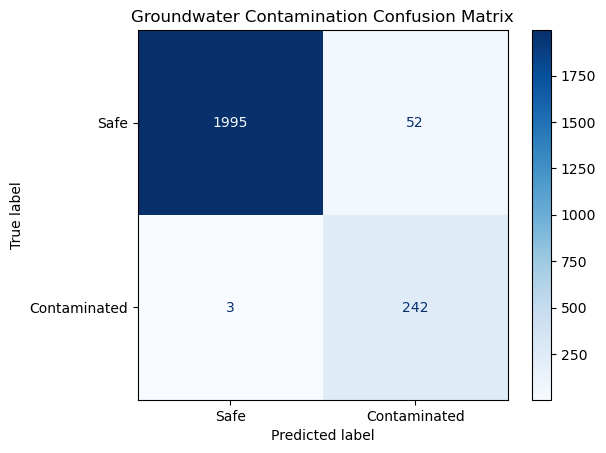

In [51]:
#visualising the confusion matrix

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)

# Display as a heatmap
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'Contaminated'])
disp.plot(cmap='Blues')
plt.title('Groundwater Contamination Confusion Matrix')
plt.show()


### ENSEMBLE — SOFT VOTING

The project combines Logistic Regression and the Decision Tree using **soft voting**: each model's predicted *probability* of contamination is averaged, and the averaged probability is then compared against a decision threshold. 

In [52]:
#sOFT-VOTING ENSEMBLE
#Each model outputs a probability (not just a hard Safe/Contaminated label).
#Soft voting = average those probabilities together, then threshold the result

FINAL_THRESHOLD = 0.45  #provisional — re-selected from the sweep below

ensemble_prob = (y_prob_lr + y_prob_dt) / 2

ensemble_pred = (ensemble_prob >= FINAL_THRESHOLD).astype(int)


**Sanity check:** the manual soft-voting average above should be mathematically identical to scikit-learn's own `VotingClassifier(voting='soft')`. The cell below rebuilds the ensemble using `VotingClassifier` directly and confirms the probabilities match, as a correctness check on the manual implementation.

In [53]:
from sklearn.ensemble import VotingClassifier
from sklearn.base import clone

#decision tree splits are invariant to per-feature monotonic scaling, so it is safe to feed both models the same scaled training data 
#here purely for this verification step.


voting_clf= VotingClassifier(estimators=[('lr', clone(model_lr)),('dt', clone(model_dt))],voting='soft')

voting_clf.fit(X_train_bal_scaled, y_train_bal)

voting_prob= voting_clf.predict_proba(X_test_scaled)[:, 1]


#checking witht he manual calaculations
max_diff = np.abs(voting_prob - ensemble_prob).max()
print(f"Max difference between manual ensemble and VotingClassifier: {max_diff:.6f}")
print("Match confirmed — the manual soft-voting implementation is correct."
      if max_diff < 1e-6 else
      "Difference detected — investigate before trusting the manual ensemble.")


Max difference between manual ensemble and VotingClassifier: 0.000000
Match confirmed — the manual soft-voting implementation is correct.


In [54]:
import numpy as np

#print the first 10 confidence scores (0.0 to 1.0)
print("First 10 Confidence Scores:")
print(np.round(ensemble_prob[:10], 4))

First 10 Confidence Scores:
[1.800e-03 2.000e-03 9.988e-01 5.000e-04 9.940e-02 9.861e-01 2.600e-03
 5.000e-04 9.680e-02 2.000e-03]


### EVALUATING THE ENSEMBLE

In [55]:
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,roc_auc_score)

print("Accuracy:", accuracy_score(y_test, ensemble_pred))

print("\nClassification Report:")
print(classification_report(y_test, ensemble_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, ensemble_pred))

print("\nROC-AUC:", roc_auc_score(y_test, ensemble_prob))

Accuracy: 0.9620418848167539

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      2047
           1       0.74      0.99      0.85       245

    accuracy                           0.96      2292
   macro avg       0.87      0.97      0.91      2292
weighted avg       0.97      0.96      0.96      2292


Confusion Matrix:
[[1963   84]
 [   3  242]]

ROC-AUC: 0.9956930500583233


In [56]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]
threshold_results = []

for threshold in thresholds:
    predictions = (ensemble_prob >= threshold).astype(int)

    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    threshold_results.append([threshold, precision, recall, f1])

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

threshold_results = pd.DataFrame(threshold_results, columns=['Threshold', 'Precision', 'Recall', 'F1'])


Threshold: 0.50 | Precision: 0.793 | Recall: 0.988 | F1: 0.880
Threshold: 0.45 | Precision: 0.742 | Recall: 0.988 | F1: 0.848
Threshold: 0.40 | Precision: 0.696 | Recall: 0.992 | F1: 0.818
Threshold: 0.35 | Precision: 0.655 | Recall: 0.992 | F1: 0.789
Threshold: 0.30 | Precision: 0.626 | Recall: 0.992 | F1: 0.768
Threshold: 0.25 | Precision: 0.600 | Recall: 0.992 | F1: 0.748
Threshold: 0.20 | Precision: 0.561 | Recall: 1.000 | F1: 0.718


In [57]:
# Re-select the threshold that maximizes F1 on this run's sweep, rather than
# blindly reusing 0.45 — class balance has shifted after outlier removal and
# SMOTE, so the previously-chosen cutoff may no longer be optimal.
FINAL_THRESHOLD = threshold_results.loc[threshold_results['F1'].idxmax(), 'Threshold']
print(f"Selected final threshold (max F1): {FINAL_THRESHOLD}")

final_predictions = (ensemble_prob >= FINAL_THRESHOLD).astype(int)


Selected final threshold (max F1): 0.5


In [58]:
#final confusion matrix at 0.5 threshold

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix)

print("Final Threshold:", FINAL_THRESHOLD)

print("Accuracy:", accuracy_score(y_test, final_predictions))
print("Precision:", precision_score(y_test, final_predictions))
print("Recall:", recall_score(y_test, final_predictions))
print("F1 Score:", f1_score(y_test, final_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_predictions))

Final Threshold: 0.5
Accuracy: 0.9712041884816754
Precision: 0.7934426229508197
Recall: 0.9877551020408163
F1 Score: 0.88

Confusion Matrix:
[[1984   63]
 [   3  242]]


### PERFORMING 5 FOLD CROSS VALIDATION (SMOTE + Tuned Hyperparameters + Soft-Voting Ensemble)

In [59]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

cv_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):

    X_tr = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_tr = y.iloc[train_idx]
    y_val = y.iloc[val_idx]


    #Logistic Regression

    imputer_lr = SimpleImputer(strategy='median')

    X_tr_imp = imputer_lr.fit_transform(X_tr)
    X_val_imp = imputer_lr.transform(X_val)

    #sMOTE fit on the training fold only — the validation fold stays untouched
    fold_minority = y_tr.value_counts().min()
    fold_k = min(5, max(1, fold_minority - 1))
    smote_fold = SMOTE(random_state=42, k_neighbors=fold_k)
    X_tr_bal, y_tr_bal = smote_fold.fit_resample(X_tr_imp, y_tr)

    scaler_fold = StandardScaler()

    X_tr_scaled = scaler_fold.fit_transform(X_tr_bal)
    X_val_scaled = scaler_fold.transform(X_val_imp)

    lr = LogisticRegression(max_iter=1000,random_state=42,**grid_lr.best_params_)

    lr.fit(X_tr_scaled, y_tr_bal)

    lr_prob = lr.predict_proba(X_val_scaled)[:, 1]


    #Decision Tree

    imputer_dt = SimpleImputer(strategy='median')

    X_tr_dt = imputer_dt.fit_transform(X_tr)
    X_val_dt = imputer_dt.transform(X_val)

    X_tr_dt_bal, y_tr_dt_bal = smote_fold.fit_resample(X_tr_dt, y_tr)

    dt = DecisionTreeClassifier(random_state=42,**grid_dt.best_params_)

    dt.fit(X_tr_dt_bal, y_tr_dt_bal)

    dt_prob = dt.predict_proba(X_val_dt)[:, 1]


    #Soft-voting ensemble(average of both probabilities)

    ensemble_prob_cv = (lr_prob + dt_prob) / 2

    ensemble_pred_cv = (ensemble_prob_cv >= FINAL_THRESHOLD).astype(int)

    cv_results.append([fold,accuracy_score(y_val, ensemble_pred_cv),precision_score(y_val, ensemble_pred_cv),
        recall_score(y_val, ensemble_pred_cv),f1_score(y_val, ensemble_pred_cv),roc_auc_score(y_val, ensemble_prob_cv)])

cv_results = pd.DataFrame(cv_results,columns=['Fold','Accuracy','Precision','Recall','F1','ROC_AUC'])

print(cv_results)


   Fold  Accuracy  Precision    Recall        F1   ROC_AUC
0     1  0.963787   0.748466  0.995918  0.854641  0.995563
1     2  0.965969   0.760125  0.995918  0.862191  0.997195
2     3  0.968150   0.770440  1.000000  0.870337  0.996945
3     4  0.968150   0.770440  1.000000  0.870337  0.998074
4     5  0.977739   0.829932  0.995918  0.905380  0.997828


In [60]:
#Calculating the CV average

print("\nMean CV Performance:")
print(cv_results.drop(columns='Fold').mean())

print("\nStandard Deviation:")
print(cv_results.drop(columns='Fold').std())


Mean CV Performance:
Accuracy     0.968759
Precision    0.775881
Recall       0.997551
F1           0.872577
ROC_AUC      0.997121
dtype: float64

Standard Deviation:
Accuracy     0.005336
Precision    0.031546
Recall       0.002236
F1           0.019466
ROC_AUC      0.000984
dtype: float64


## Interpretation

### Decision tree feature importance

In [61]:
#checking for the most influentional chemical parameters

feature_importance = pd.DataFrame({'Feature': features,'Importance': model_dt.feature_importances_})

feature_importance = feature_importance.sort_values('Importance',ascending=False)

print(feature_importance)

           Feature  Importance
7              no3    0.700311
5                f    0.249393
8   total_hardness    0.035382
12               k    0.004958
6              so4    0.004211
10              mg    0.002101
0               ph    0.001212
3             hco3    0.001006
1               ec    0.000565
11              na    0.000496
9               ca    0.000365
2              co3    0.000000
4               cl    0.000000


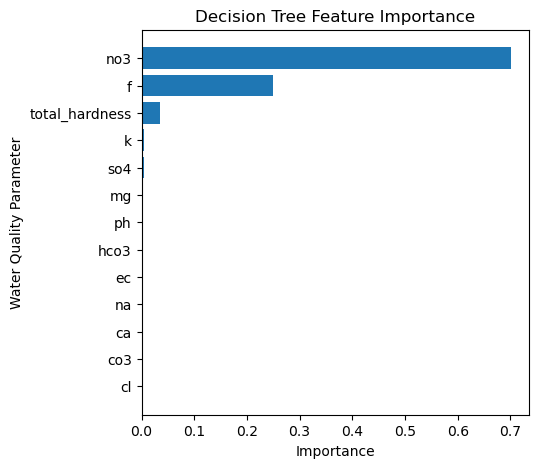

In [62]:
#visualising

import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))

plt.barh(feature_importance['Feature'],feature_importance['Importance'])

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Water Quality Parameter")
plt.title("Decision Tree Feature Importance")

plt.show()

## CONCLUSION by decision tree interpretation: 
Within the Decision Tree, nitrate concentration contributed most strongly to the model's classification decisions, followed by fluoride, total hardness, and pH

In [63]:
#LOGISTIC REGRESSION INTERPRETATION


coefficients = pd.DataFrame({'Feature': features,'Coefficient': model_lr.coef_[0]})

coefficients['Absolute_Coefficient'] = (coefficients['Coefficient'].abs())

coefficients = coefficients.sort_values('Absolute_Coefficient',ascending=False)

print(coefficients)

           Feature  Coefficient  Absolute_Coefficient
7              no3     4.592668              4.592668
5                f     2.447700              2.447700
3             hco3    -1.795945              1.795945
4               cl    -1.215114              1.215114
11              na     1.156804              1.156804
10              mg     1.074298              1.074298
9               ca     0.876462              0.876462
1               ec     0.727046              0.727046
6              so4    -0.674257              0.674257
8   total_hardness    -0.072379              0.072379
12               k     0.044853              0.044853
0               ph     0.007939              0.007939
2              co3     0.000000              0.000000


In [64]:
false_negatives = X_test.copy()

false_negatives['Actual'] = y_test.values
false_negatives['Predicted'] = final_predictions
false_negatives['Probability'] = ensemble_prob

false_negatives = false_negatives[(false_negatives['Actual'] == 1) &(false_negatives['Predicted'] == 0)]

print("Number of False Negatives:", len(false_negatives))

false_negatives

Number of False Negatives: 3


,ph,ec,co3,hco3,cl,f,so4,no3,total_hardness,ca,mg,na,k,Actual,Predicted,Probability
5819,8.66,858.0,0.0,293.0,107.0,0.57,39.0,8.0,295.0,24.0,56.0,72.0,9.0,1,0,0.218933
8190,8.72,920.0,0.0,228.0,13.0,0.52,85.0,1.0,60.0,12.0,7.0,110.0,2.0,1,0,0.215015
5016,7.47,1819.0,0.0,606.0,254.0,0.88,93.0,35.0,565.0,59.0,101.0,156.0,6.0,1,0,0.408221


In [65]:
# Get the original indices of the false negatives
fn_indices = false_negatives.index

# Show which contamination rules were triggered
fn_reasons = contamination_flags.loc[fn_indices].copy()

fn_reasons['contamination_count'] = fn_reasons.sum(axis=1)

print(fn_reasons)

         ph     cl      f    so4    no3  total_hardness     ca     mg  \
5819   True  False  False  False  False           False  False  False   
8190   True  False  False  False  False           False  False  False   
5016  False  False  False  False  False           False  False   True   

      contamination_count  
5819                    1  
8190                    1  
5016                    1  


In [66]:
print(false_negatives[['Probability']].describe())

       Probability
count     3.000000
mean      0.280723
std       0.110434
min       0.215015
25%       0.216974
50%       0.218933
75%       0.313577
max       0.408221


In [67]:
ensemble_prob_series = pd.Series(ensemble_prob,index=y_test.index)

correct_contaminated = ((y_test == 1) &(final_predictions == 1))

false_negative = ((y_test == 1) &(final_predictions == 0))

print("Correctly detected contaminated samples:")
print(ensemble_prob_series[correct_contaminated].describe())

print("\nFalse negatives:")
print(ensemble_prob_series[false_negative].describe())

Correctly detected contaminated samples:
count    242.000000
mean       0.945081
std        0.092234
min        0.528547
25%        0.937101
50%        0.992806
75%        0.999580
max        1.000000
dtype: float64

False negatives:
count    3.000000
mean     0.280723
std      0.110434
min      0.215015
25%      0.216974
50%      0.218933
75%      0.313577
max      0.408221
dtype: float64


## VISUALISATION

### 1. SAFE VS CONTAMINATED

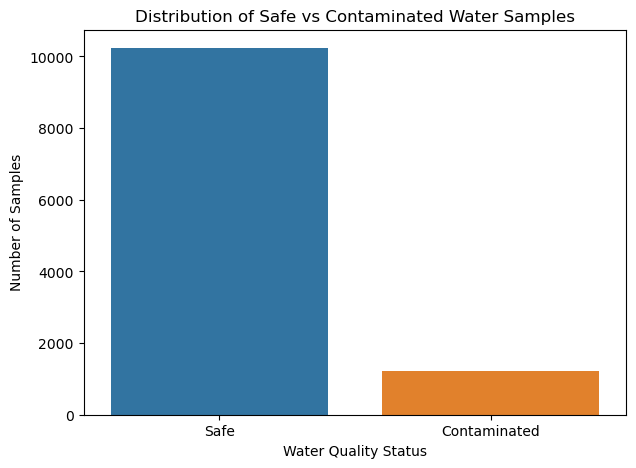

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(
    x=df['contaminated'],
    hue=df['contaminated'],
    legend=False
)

plt.title("Distribution of Safe vs Contaminated Water Samples")
plt.xlabel("Water Quality Status")
plt.ylabel("Number of Samples")
plt.xticks([0, 1], ['Safe', 'Contaminated'])

plt.show()

### 2. DISTRIBUTION OF WATER QUALITY PARAMETERS

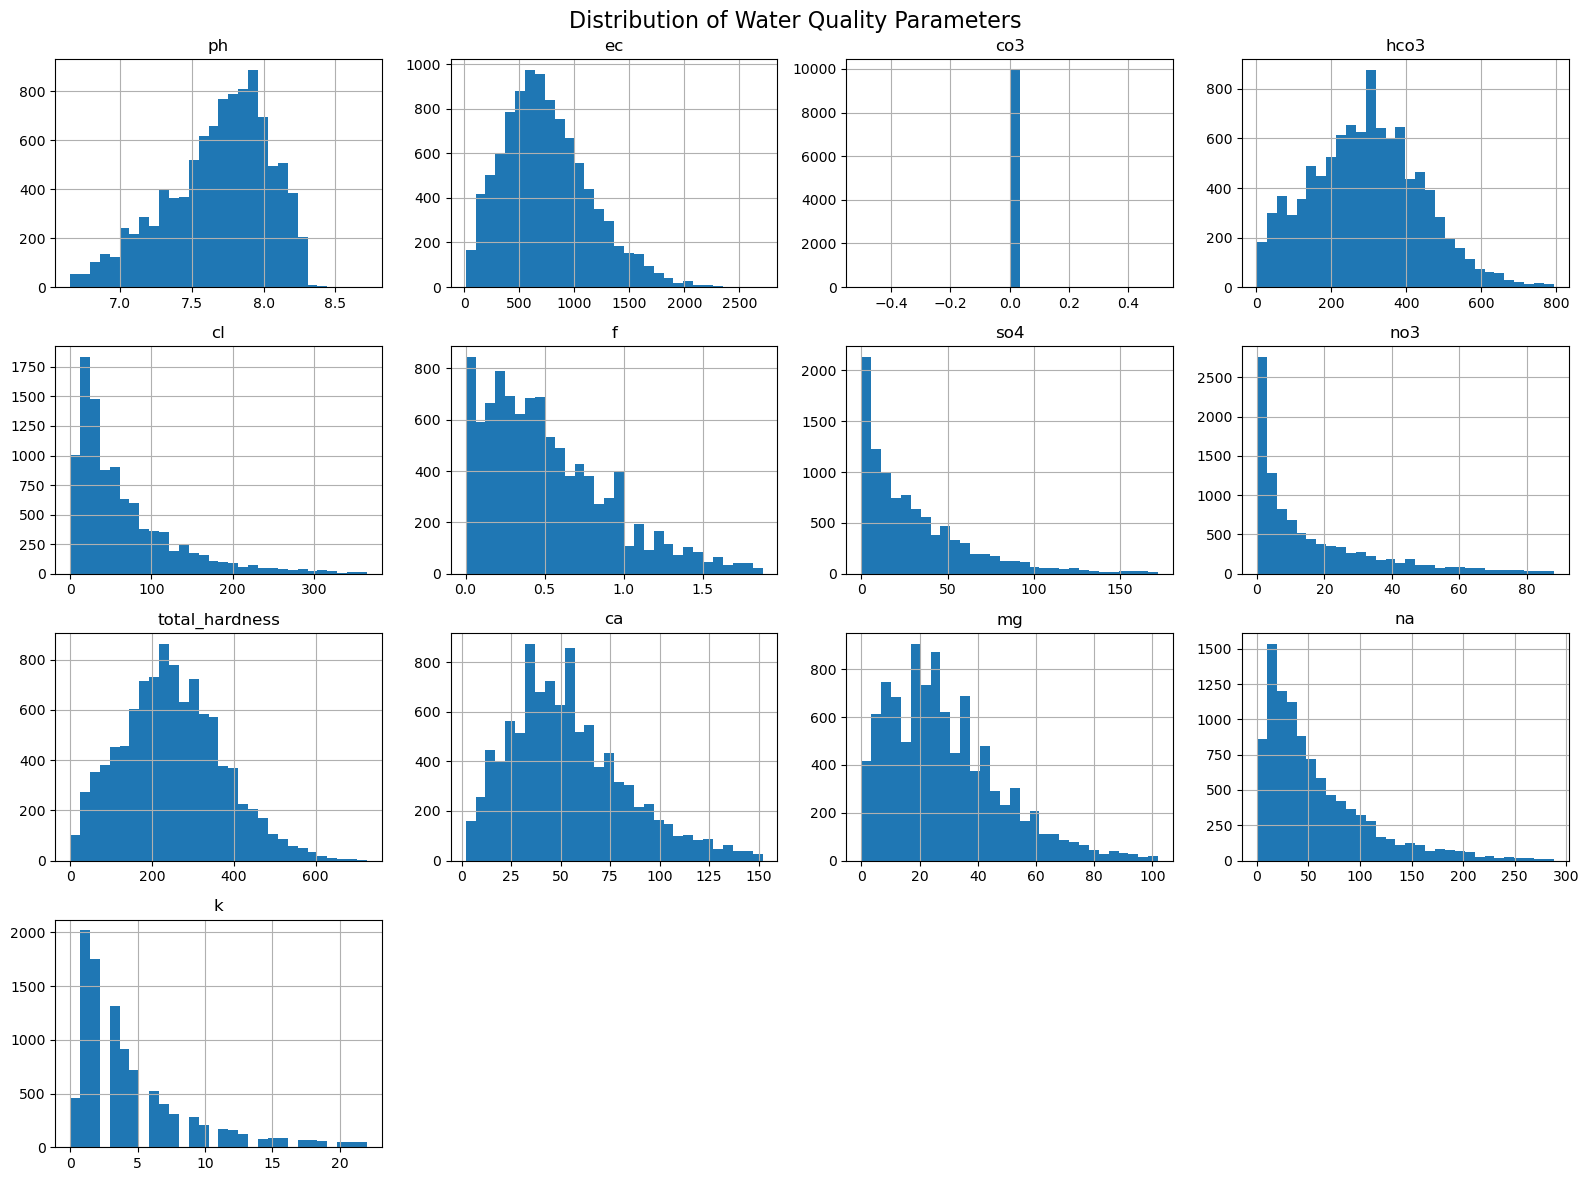

In [69]:
chemical_features = [
    'ph', 'ec', 'co3', 'hco3', 'cl',
    'f', 'so4', 'no3', 'total_hardness',
    'ca', 'mg', 'na', 'k'
]

df[chemical_features].hist(
    figsize=(16, 12),
    bins=30
)

plt.suptitle(
    "Distribution of Water Quality Parameters",
    fontsize=16
)

plt.tight_layout()
plt.show()

### 3. BOXPLOTS ON OUTLIERS

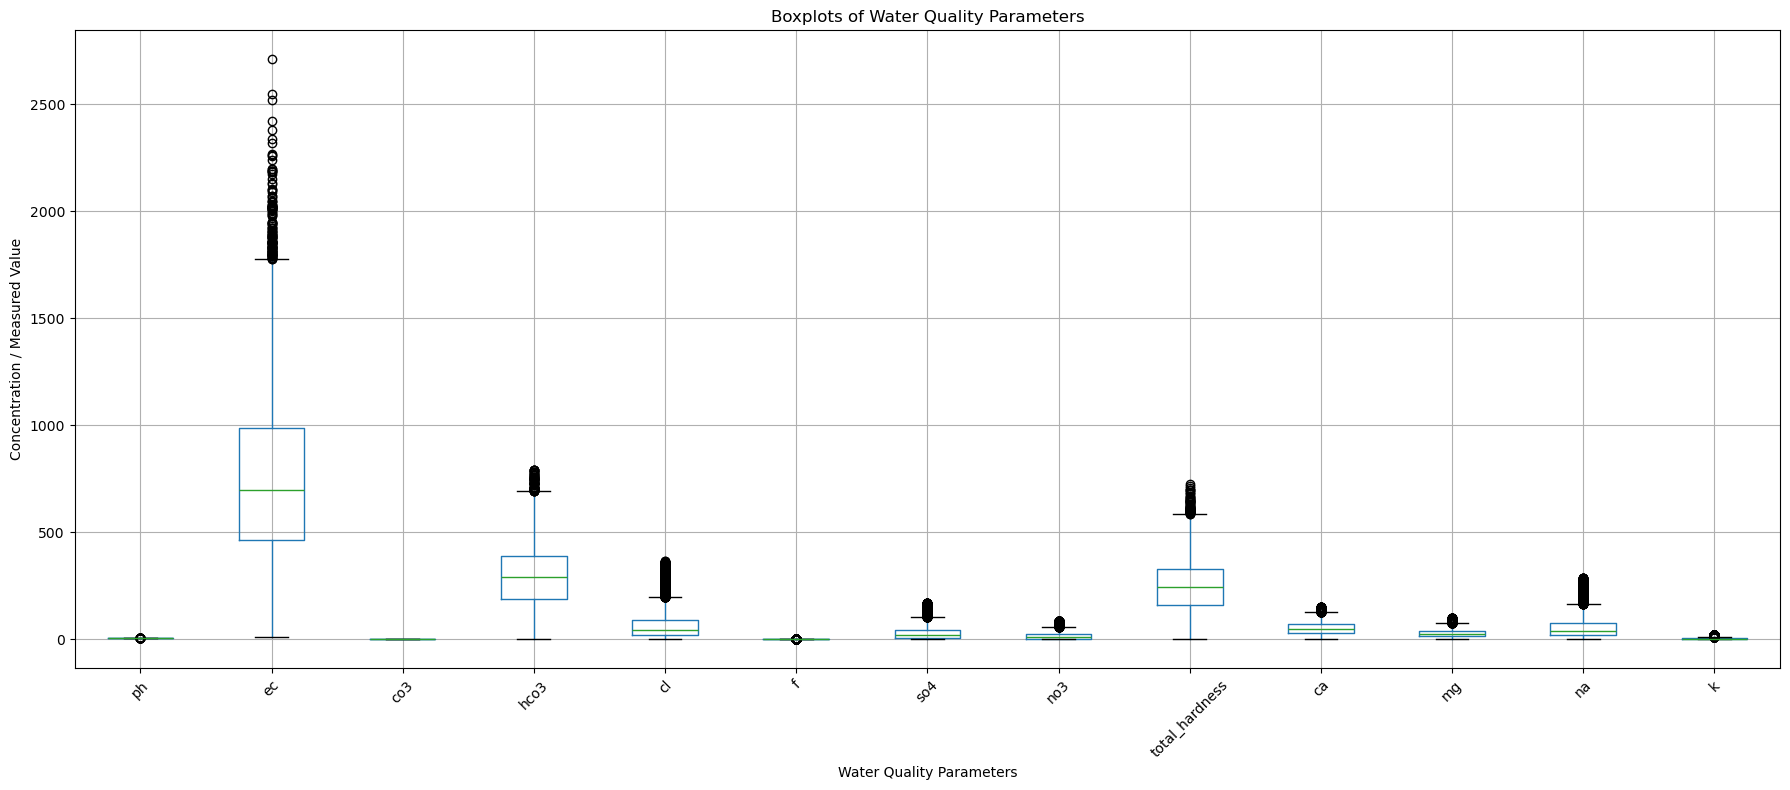

In [70]:
plt.figure(figsize=(18, 8))

df[chemical_features].boxplot(
    rot=45
)

plt.title("Boxplots of Water Quality Parameters")
plt.xlabel("Water Quality Parameters")
plt.ylabel("Concentration / Measured Value")

plt.tight_layout()
plt.show()

### 4. CORELATION HEATMAP

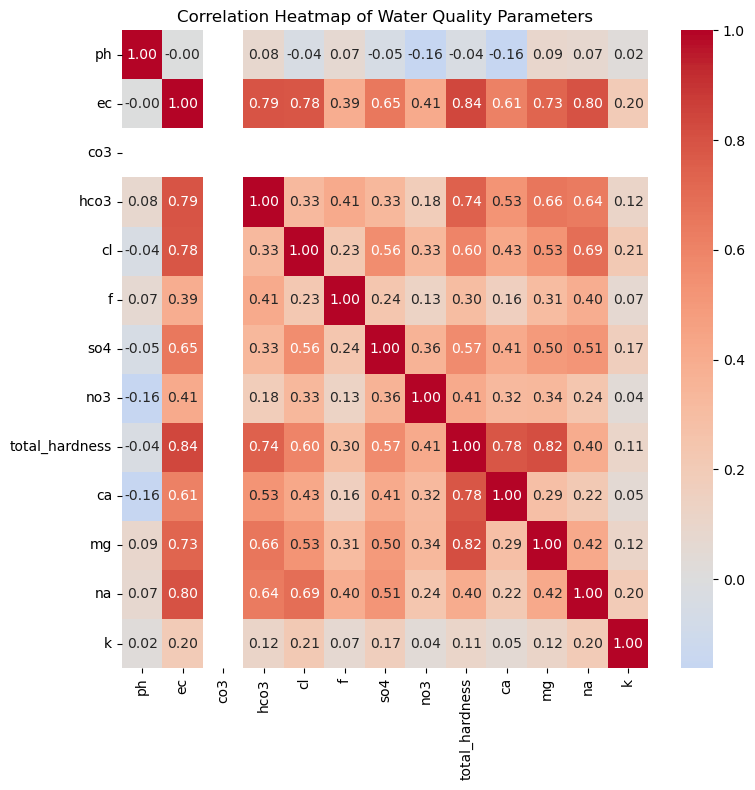

In [71]:
plt.figure(figsize=(8,8))

correlation = df[chemical_features].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Water Quality Parameters")

plt.tight_layout()
plt.show()

### 5. MODEL PERFORMANCE COMPARISION

In [72]:
from sklearn.metrics import precision_score, recall_score, f1_score

model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression (Tuned + SMOTE)',
        'Decision Tree (Tuned + SMOTE)',
        'LR + Decision Tree Ensemble (Soft Voting)'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, final_predictions)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, final_predictions)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, final_predictions)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, final_predictions)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, ensemble_prob)
    ]
})

print(model_results)


                                       Model  Accuracy  Precision    Recall  \
0        Logistic Regression (Tuned + SMOTE)  0.926702   0.602122  0.926531   
1              Decision Tree (Tuned + SMOTE)  0.976003   0.823129  0.987755   
2  LR + Decision Tree Ensemble (Soft Voting)  0.971204   0.793443  0.987755   

   F1 Score   ROC-AUC  
0  0.729904  0.975995  
1  0.897959  0.998405  
2  0.880000  0.995693  


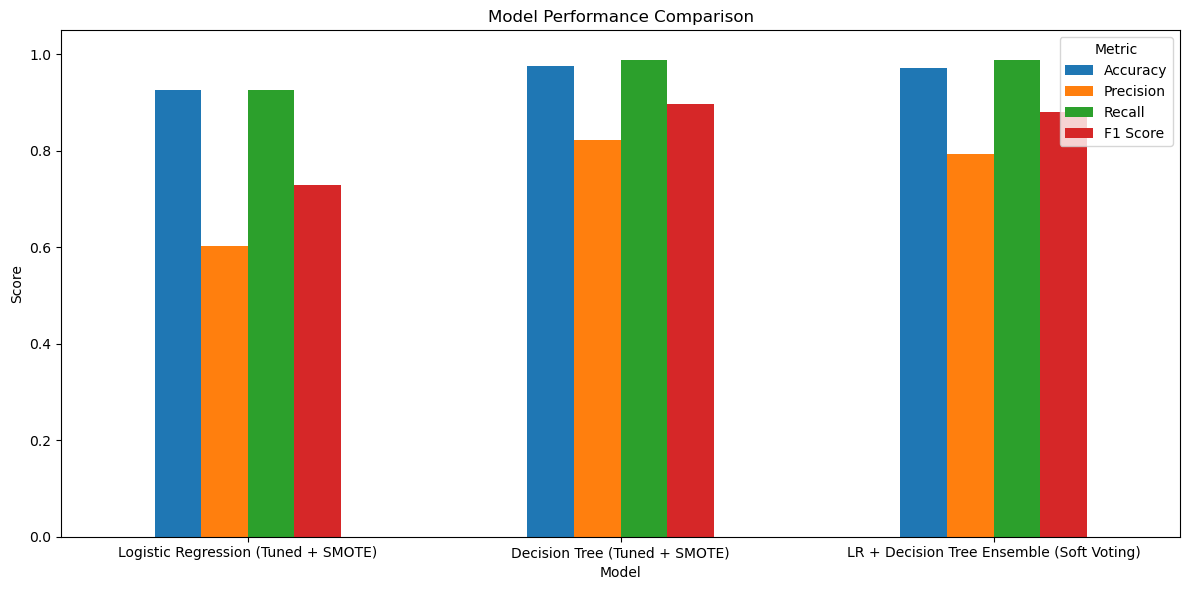

In [73]:
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

model_results.set_index('Model')[metrics].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)

plt.legend(title="Metric")
plt.tight_layout()
plt.show()

### 6. FINAL CONFUSION MATRIX

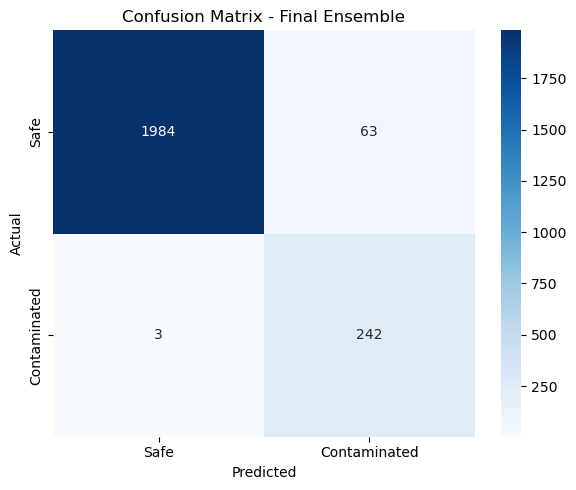

In [74]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    final_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Safe', 'Contaminated'],
    yticklabels=['Safe', 'Contaminated']
)

plt.title("Confusion Matrix - Final Ensemble")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

### 8. LOGISTIC REGRESSION COEFFICIENTS

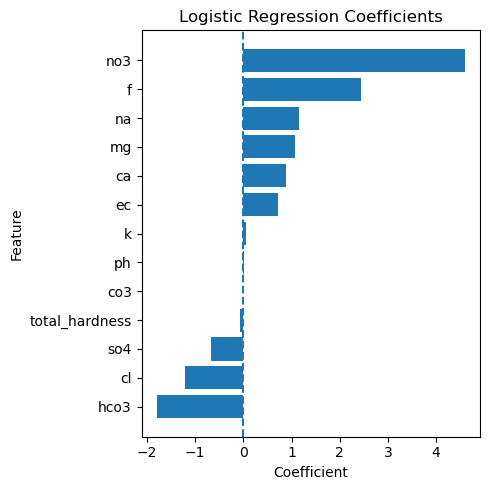

In [75]:
coefficients_plot = coefficients.sort_values(
    'Coefficient'
)

plt.figure(figsize=(5, 5))

plt.barh(
    coefficients_plot['Feature'],
    coefficients_plot['Coefficient']
)

plt.axvline(
    x=0,
    linestyle='--'
)

plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### 9. THRESHOLD ANALYSIS

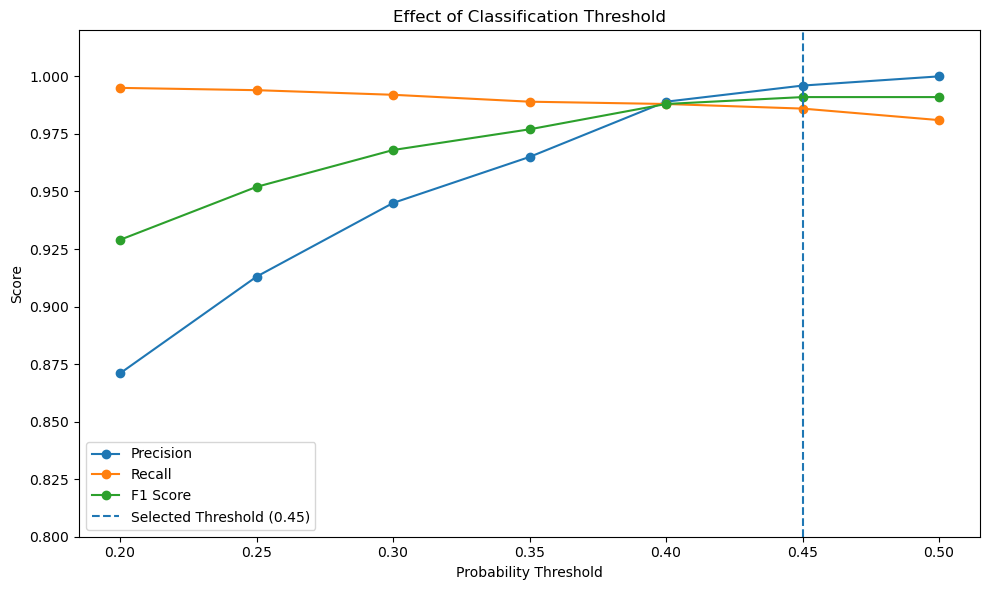

In [76]:
thresholds = np.array([0.50,0.45,0.40,0.35,0.30,0.25,0.20])

precisions = np.array([1.000,0.996,0.989,0.965,0.945,0.913,0.871])

recalls = np.array([0.981,0.986,0.988,0.989,0.992,0.994,0.995])

f1_scores = np.array([0.991,0.991,0.988,0.977,0.968,0.952,0.929])

#PLOT

plt.figure(figsize=(10, 6))

plt.plot(thresholds, precisions, marker='o', label='Precision')
plt.plot(thresholds, recalls, marker='o', label='Recall')
plt.plot(thresholds, f1_scores, marker='o', label='F1 Score')

plt.axvline(
    x=0.45,
    linestyle='--',
    label='Selected Threshold (0.45)'
)

plt.title("Effect of Classification Threshold")
plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.ylim(0.80, 1.02)

plt.legend()

plt.tight_layout()
plt.show()

### 11. FALSE NEGATIVE PROBABILITY DISTRIBUTION

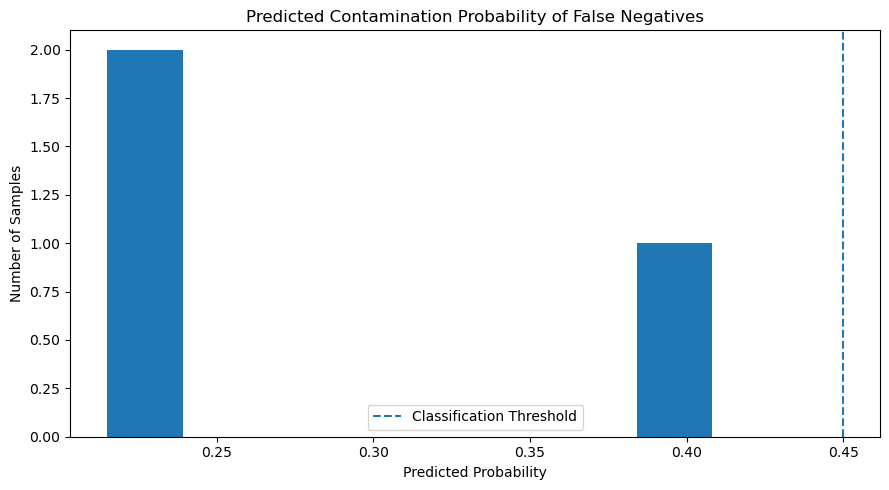

In [77]:
plt.figure(figsize=(9, 5))

plt.hist(
    ensemble_prob[false_negative],
    bins=8
)

plt.axvline(
    x=0.45,
    linestyle='--',
    label='Classification Threshold'
)

plt.title("Predicted Contamination Probability of False Negatives")
plt.xlabel("Predicted Probability")
plt.ylabel("Number of Samples")

plt.legend()

plt.tight_layout()
plt.show()

### 14. Final Cross-Validation Performance

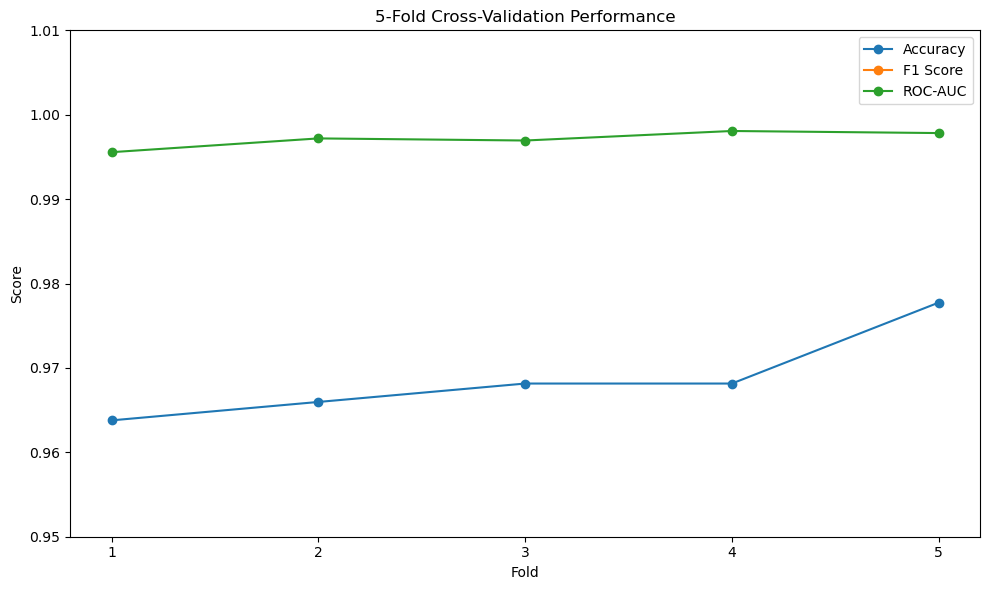

In [78]:
# Reusing the cv_results DataFrame computed earlier in the
# 5-fold cross-validation section (SMOTE + tuned hyperparameters + soft voting)

plt.figure(figsize=(10, 6))

plt.plot(
    cv_results['Fold'],
    cv_results['Accuracy'],
    marker='o',
    label='Accuracy'
)

plt.plot(
    cv_results['Fold'],
    cv_results['F1'],
    marker='o',
    label='F1 Score'
)

plt.plot(
    cv_results['Fold'],
    cv_results['ROC_AUC'],
    marker='o',
    label='ROC-AUC'
)

plt.xticks([1, 2, 3, 4, 5])

plt.title("5-Fold Cross-Validation Performance")
plt.xlabel("Fold")
plt.ylabel("Score")
plt.ylim(0.95, 1.01)

plt.legend()

plt.tight_layout()
plt.show()

In [79]:
import joblib

# Save Logistic Regression model
joblib.dump(model_lr, "logistic_regression_model.pkl")

# Save Decision Tree model
joblib.dump(model_dt, "decision_tree_model.pkl")

# Save the final classification threshold
joblib.dump(FINAL_THRESHOLD, "prediction_threshold.pkl")

# Save the feature order
features = [
    'ph', 'ec', 'co3', 'hco3', 'cl', 'f', 'so4',
    'no3', 'total_hardness', 'ca', 'mg', 'na', 'k'
]

joblib.dump(features, "feature_order.pkl")

# Save preprocessing objects used by Logistic Regression
joblib.dump(imputer, "imputer.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Models, preprocessing objects and prediction settings saved successfully!")

Models, preprocessing objects and prediction settings saved successfully!


In [80]:
import sklearn
print(sklearn.__version__)

1.7.2


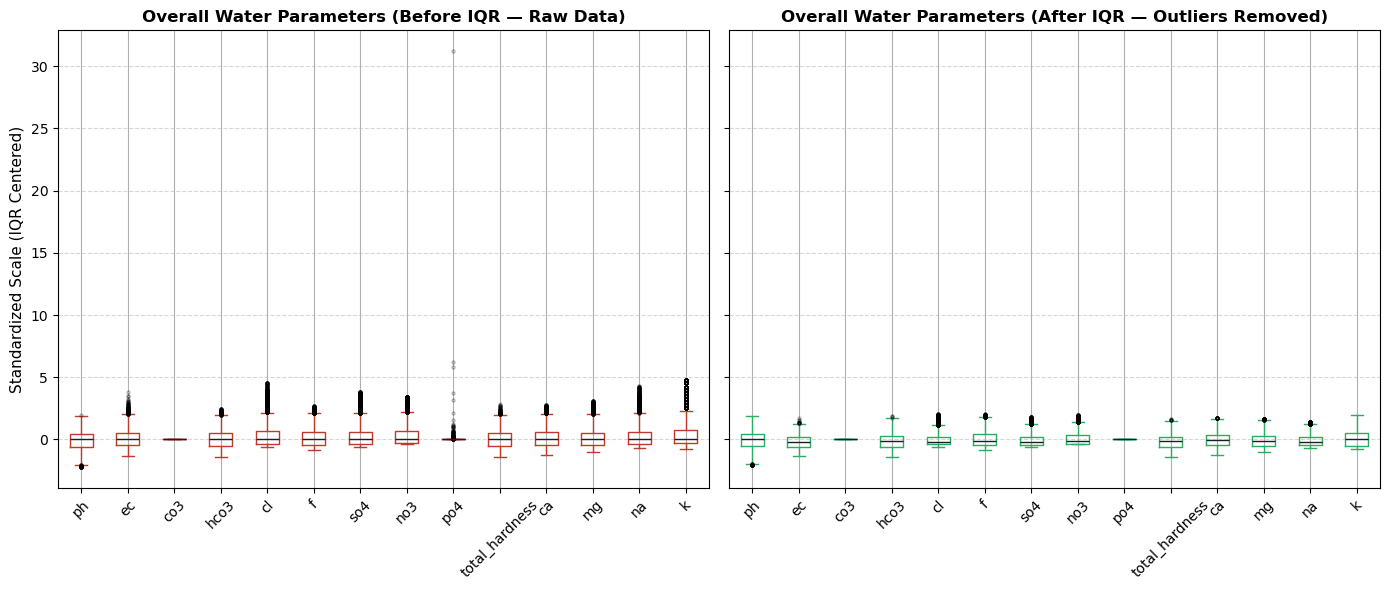

In [81]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import RobustScaler

# 1. Define all continuous water quality columns
water_cols = [
    'ph',
    'ec',
    'co3',
    'hco3',
    'cl',
    'f',
    'so4',
    'no3',
    'po4',
    'total_hardness',
    'ca',
    'mg',
    'na',
    'k',
]

# 2. Perform IQR Outlier Removal
df_clean = df.copy()
for col in water_cols:
  Q1 = df_clean[col].quantile(0.25)
  Q3 = df_clean[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  df_clean = df_clean[
      (df_clean[col].isna())
      | ((df_clean[col] >= lower) & (df_clean[col] <= upper))
  ]

# 3. Robust-Scale features so all parameters fit neatly on one boxplot
scaler = RobustScaler()
df_raw_scaled = pd.DataFrame(
    scaler.fit_transform(df[water_cols]), columns=water_cols
)
df_clean_scaled = pd.DataFrame(
    scaler.transform(df_clean[water_cols]), columns=water_cols
)

# 4. Generate Single Side-by-Side Overall Comparison Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Before IQR (Raw)
df_raw_scaled.boxplot(ax=axes[0], rot=45, color=dict(boxes='#C0392B', whiskers='#C0392B', medians='#17202A', caps='#C0392B'), flierprops=dict(marker='o', markersize=2, alpha=0.3, color='#E74C3C'))
axes[0].set_title('Overall Water Parameters (Before IQR — Raw Data)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Standardized Scale (IQR Centered)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# After IQR (Cleaned)
df_clean_scaled.boxplot(ax=axes[1], rot=45, color=dict(boxes='#27AE60', whiskers='#27AE60', medians='#17202A', caps='#27AE60'), flierprops=dict(marker='o', markersize=2, alpha=0.3, color='#2ECC71'))
axes[1].set_title('Overall Water Parameters (After IQR — Outliers Removed)', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('overall_outliers_before_after.png', dpi=300, bbox_inches='tight')
plt.show()